# Demonstration of distribution reweighting

**hep_ml.reweight** contains methods to reweight distributions. 
Typically we use reweighting of monte-carlo to fight drawbacks of simulation, though there are many applications.

In this example we reweight multidimensional distibutions: `original` and `target`, the aim is to find new weights for original distribution, such that these multidimensional distributions will coincide. 

Here we have a __toy example__ without a real physics meaning.

Pay attention: equality of distibutions for each feature $\neq$ equality of multivariate distributions.

All samples are divided into **training** and **validation** part. Training part is used to fit reweighting rule and test part is used to estimate reweighting quality.

In [3]:
%matplotlib inline

import numpy
import uproot

# import root_numpy
import uproot
import pandas
from hep_ml import reweight
from matplotlib import pyplot as plt

### Downloading data

In [6]:
storage = 'https://github.com/arogozhnikov/hep_ml/blob/data/data_to_download/'
!wget -O ./data/MC_distribution.root -nc $storage/MC_distribution.root?raw=true
!wget -O ./data/RD_distribution.root -nc $storage/RD_distribution.root?raw=true

--2024-12-21 03:10:09--  https://github.com/arogozhnikov/hep_ml/blob/data/data_to_download//MC_distribution.root?raw=true
github.com (github.com) 해석 중... 20.200.245.247
다음으로 연결 중: github.com (github.com)|20.200.245.247|:443... 연결했습니다.
HTTP 요청을 보냈습니다. 응답 기다리는 중... 302 Found
위치: https://github.com/arogozhnikov/hep_ml/raw/refs/heads/data/data_to_download/MC_distribution.root [따라감]
--2024-12-21 03:10:10--  https://github.com/arogozhnikov/hep_ml/raw/refs/heads/data/data_to_download/MC_distribution.root
github.com에 기존 연결 재활용:443.
HTTP 요청을 보냈습니다. 응답 기다리는 중... 302 Found
위치: https://raw.githubusercontent.com/arogozhnikov/hep_ml/refs/heads/data/data_to_download/MC_distribution.root [따라감]
--2024-12-21 03:10:10--  https://raw.githubusercontent.com/arogozhnikov/hep_ml/refs/heads/data/data_to_download/MC_distribution.root
raw.githubusercontent.com (raw.githubusercontent.com) 해석 중... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
다음으로 연결 중: raw.githubusercontent.com (raw.githubusercontent.com

In [3]:
# columns = ['hSPD', 'pt_b', 'pt_phi', 'vchi2_b', 'mu_pt_sum']

# original = root_numpy.root2array('../data/MC_distribution.root', branches=columns)
# target = root_numpy.root2array('../data/RD_distribution.root', branches=columns)

# original = pandas.DataFrame(original)
# target = pandas.DataFrame(target)

# original_weights = numpy.ones(len(original))

In [9]:
columns = ['hSPD', 'pt_b', 'pt_phi', 'vchi2_b', 'mu_pt_sum']

# Load data from the ROOT file using uproot
original_file = uproot.open('./data/MC_distribution.root')
target_file = uproot.open('./data/RD_distribution.root')

# Convert the branches into Pandas DataFrames
original = original_file["tree"].arrays(columns, library="pd")
target = target_file["tree"].arrays(columns, library="pd")

# Create weights for the original dataset
original_weights = numpy.ones(len(original))

# Display results
print(original.head())
print(target.head())

   hSPD       pt_b    pt_phi    vchi2_b  mu_pt_sum
0   199   1.616341  2.022476  13.996979   6.465363
1   141   8.054563  1.394660   5.611774  32.218250
2   265  13.330556  2.424426   7.489416  53.322224
3   114   7.071134  4.256384  13.365418  28.284534
4   310   2.398052  0.867687   6.861138   9.592206
   hSPD      pt_b    pt_phi    vchi2_b  mu_pt_sum
0   577  6.616884  2.606328   5.234917  26.467535
1   527  1.442879  0.993363  42.930290   5.771515
2   419  4.669534  1.075880   3.556069  18.678137
3   598  4.358034  2.724430  61.136471  17.432135
4   505  5.480070  1.374339  46.047203  21.920280


### prepare train and test samples

* train part is used to train reweighting rule
* test part is used to evaluate reweighting rule comparing the following things: 
    * Kolmogorov-Smirnov distances for 1d projections
    * n-dim distibutions using ML (see below).

In [10]:
from sklearn.model_selection import train_test_split
# divide original samples into training ant test parts
original_train, original_test = train_test_split(original)
# divide target samples into training ant test parts
target_train, target_test = train_test_split(target)

original_weights_train = numpy.ones(len(original_train))
original_weights_test = numpy.ones(len(original_test))

In [11]:
from hep_ml.metrics_utils import ks_2samp_weighted
hist_settings = {'bins': 100, 'density': True, 'alpha': 0.7}

def draw_distributions(original, target, new_original_weights):
    plt.figure(figsize=[15, 7])
    for id, column in enumerate(columns, 1):
        xlim = numpy.percentile(numpy.hstack([target[column]]), [0.01, 99.99])
        plt.subplot(2, 3, id)
        plt.hist(original[column], weights=new_original_weights, range=xlim, **hist_settings)
        plt.hist(target[column], range=xlim, **hist_settings)
        plt.title(column)
        print('KS over ', column, ' = ', ks_2samp_weighted(original[column], target[column], 
                                         weights1=new_original_weights, weights2=numpy.ones(len(target), dtype=float)))

### Notice:
Setting `density=True` in `hist_settings` above means that the histograms will be drawn normalized below, so that the area under each histogram integrates to 1. This can obscure the fact that the weights produced by `predict_weights` are not normalized; if you want the number of effective events to be the same after reweighting, you must renormalize the weights manually--see the `reweight` documentation.


## Original distributions
KS = Kolmogorov-Smirnov distance

In [12]:
# pay attention, actually we have very few data
len(original), len(target)

(1000000, 21441)

KS over  hSPD  =  0.5203540728277889
KS over  pt_b  =  0.21639364439970188
KS over  pt_phi  =  0.4020113592414034
KS over  vchi2_b  =  0.40466385087324064
KS over  mu_pt_sum  =  0.21639364439970188


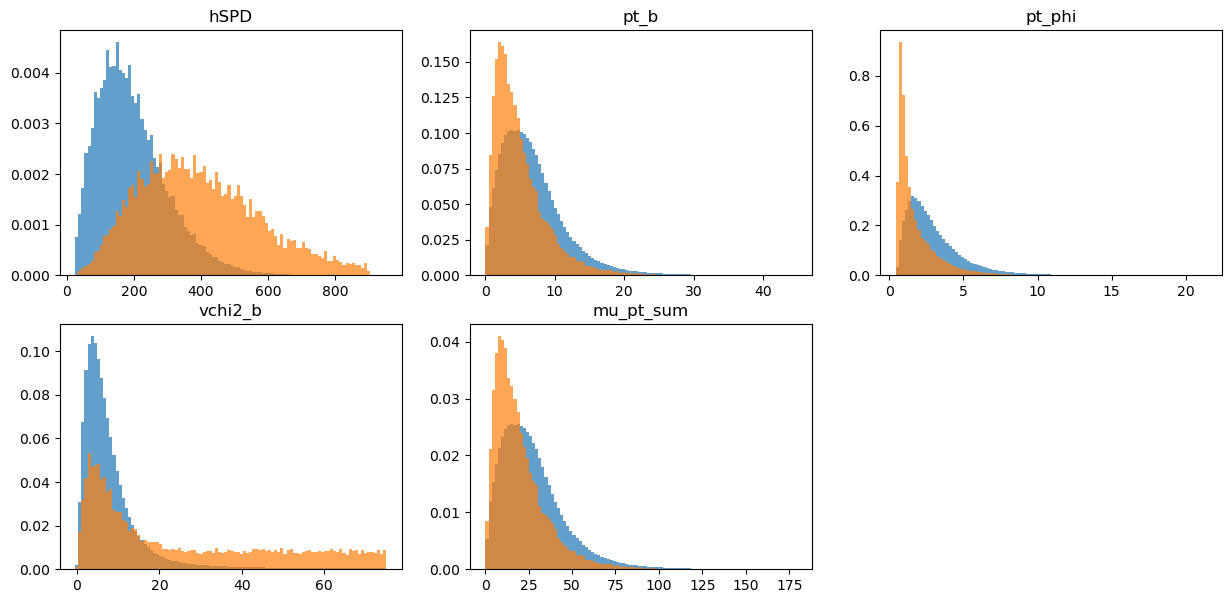

In [13]:
draw_distributions(original, target, original_weights)

### train part of original distribution

KS over  hSPD  =  0.5190657611940196
KS over  pt_b  =  0.21581195024740762
KS over  pt_phi  =  0.40242850746280934
KS over  vchi2_b  =  0.4054882487501938
KS over  mu_pt_sum  =  0.21581195024740762


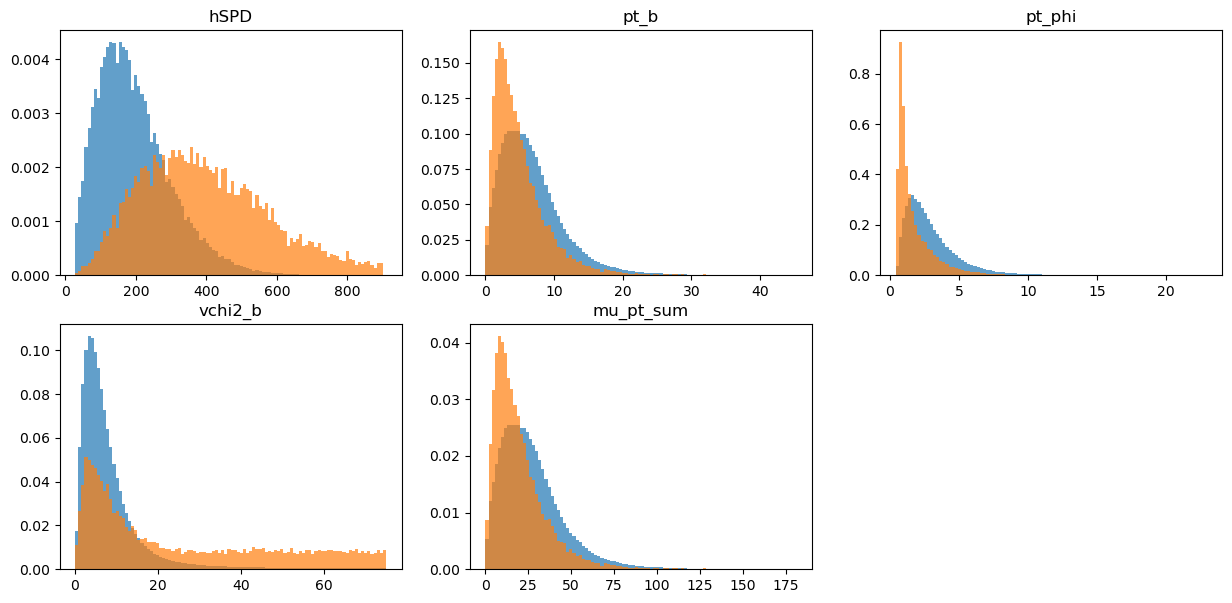

In [14]:
draw_distributions(original_train, target_train, original_weights_train)

### test part for target distribution

KS over  hSPD  =  0.5273584607349481
KS over  pt_b  =  0.2220369852636166
KS over  pt_phi  =  0.4015872893115756
KS over  vchi2_b  =  0.4037054523418087
KS over  mu_pt_sum  =  0.2220369852636166


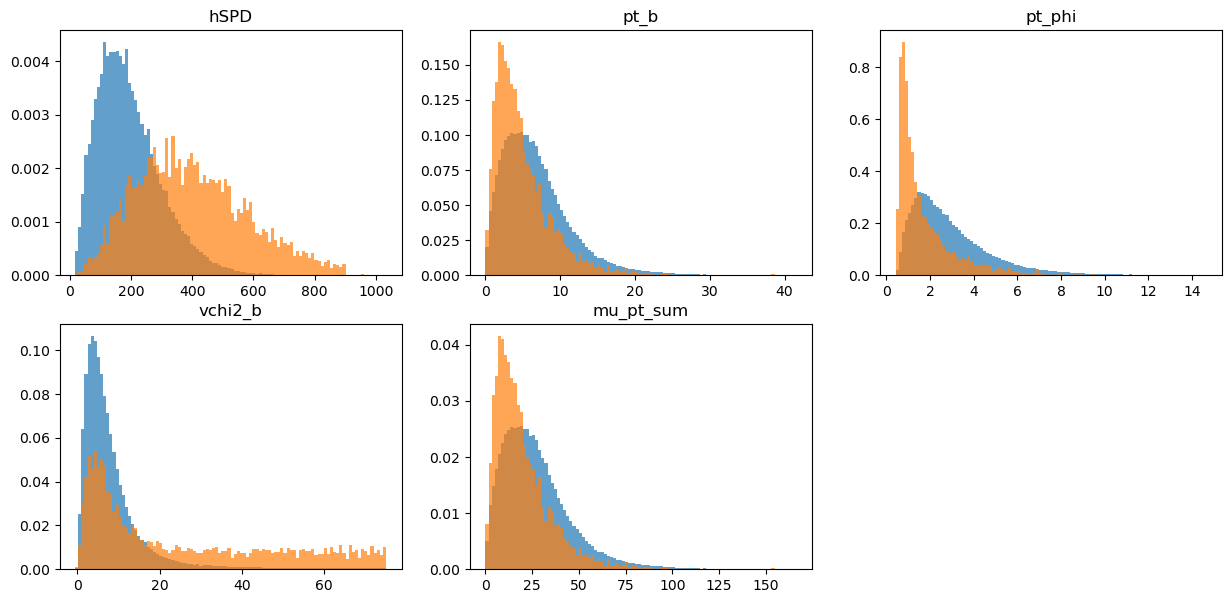

In [15]:
draw_distributions(original_test, target_test, original_weights_test)

# Bins-based reweighting in n dimensions
Typical way to reweight distributions is based on bins.

KS over  hSPD  =  0.30257035267210786
KS over  pt_b  =  0.08576697616134077
KS over  pt_phi  =  0.15148935941756791
KS over  vchi2_b  =  0.2615312980927512
KS over  mu_pt_sum  =  0.08576697616134077


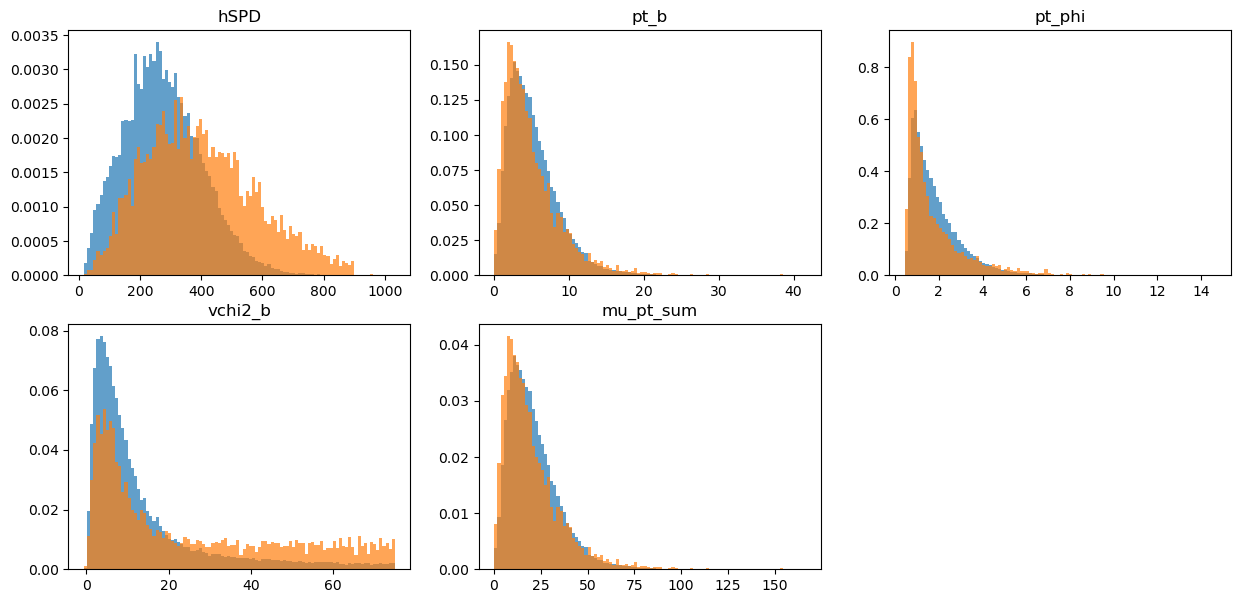

In [16]:
bins_reweighter = reweight.BinsReweighter(n_bins=20, n_neighs=1.)
bins_reweighter.fit(original_train, target_train)

bins_weights_test = bins_reweighter.predict_weights(original_test)
# validate reweighting rule on the test part comparing 1d projections
draw_distributions(original_test, target_test, bins_weights_test)

# Gradient Boosted Reweighter

This algorithm is inspired by gradient boosting and is able to fight curse of dimensionality.
It uses decision trees and special loss functiion (**ReweightLossFunction**).

**GBReweighter** supports negative weights (to reweight MC to splotted real data).

KS over  hSPD  =  0.04466016918200211
KS over  pt_b  =  0.03318311402035623
KS over  pt_phi  =  0.030050206344991004
KS over  vchi2_b  =  0.024363670205215404
KS over  mu_pt_sum  =  0.03318311402035623


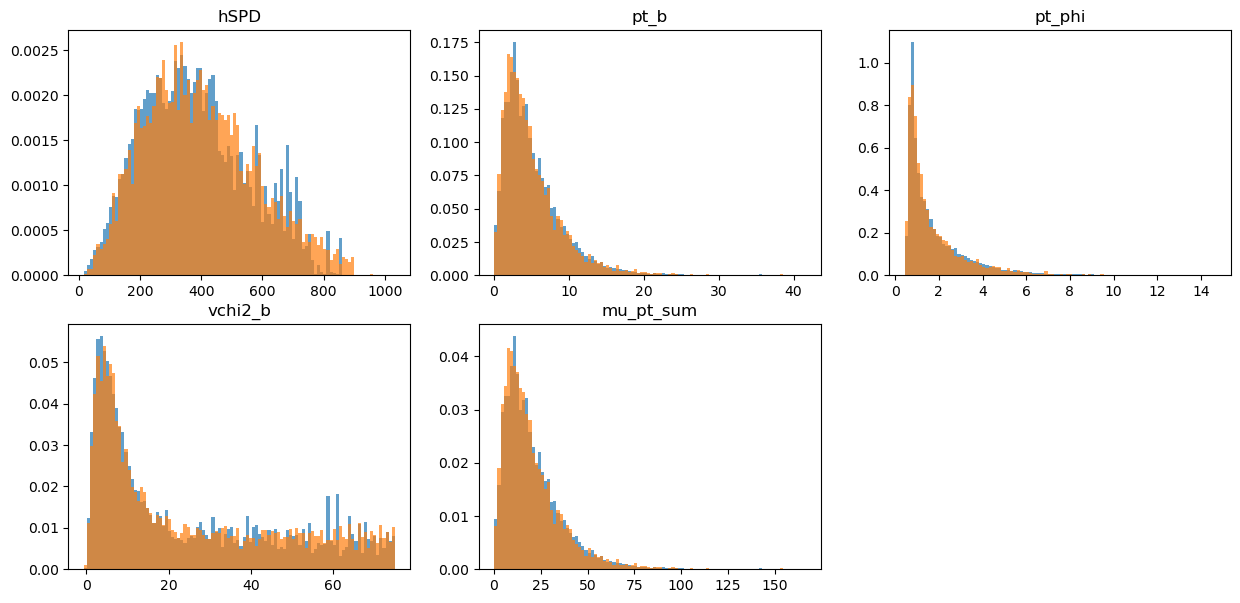

In [17]:
reweighter = reweight.GBReweighter(n_estimators=50, learning_rate=0.1, max_depth=3, min_samples_leaf=1000, 
                                   gb_args={'subsample': 0.4})
reweighter.fit(original_train, target_train)

gb_weights_test = reweighter.predict_weights(original_test)
# validate reweighting rule on the test part comparing 1d projections
draw_distributions(original_test, target_test, gb_weights_test)

## Comparing some simple expressions:
the most interesting is checking some other variables in multidimensional distributions (those are expressed via original variables).

In [18]:
def check_ks_of_expression(expression):
    col_original = original_test.eval(expression, engine='python')
    col_target = target_test.eval(expression, engine='python')
    w_target = numpy.ones(len(col_target), dtype='float')
    print('No reweight   KS:', ks_2samp_weighted(col_original, col_target, 
                                                 weights1=original_weights_test, weights2=w_target))
    print('Bins reweight KS:', ks_2samp_weighted(col_original, col_target, 
                                                 weights1=bins_weights_test, weights2=w_target))
    print('GB Reweight   KS:', ks_2samp_weighted(col_original, col_target,
                                                 weights1=gb_weights_test, weights2=w_target))

In [19]:
check_ks_of_expression('hSPD')

No reweight   KS: 0.5273584607349481
Bins reweight KS: 0.30257035267210786
GB Reweight   KS: 0.04466016918200211


In [20]:
check_ks_of_expression('hSPD * pt_phi')

No reweight   KS: 0.09254730647287901
Bins reweight KS: 0.13017353693078373
GB Reweight   KS: 0.015985450102411092


In [21]:
check_ks_of_expression('hSPD * pt_phi * vchi2_b')

No reweight   KS: 0.3680230318977646
Bins reweight KS: 0.2761643252406114
GB Reweight   KS: 0.02373000967042091


In [22]:
check_ks_of_expression('pt_b * pt_phi / hSPD ')

No reweight   KS: 0.47953470882286764
Bins reweight KS: 0.2810697371398178
GB Reweight   KS: 0.05100619384702565


In [23]:
check_ks_of_expression('hSPD * pt_b * vchi2_b / pt_phi')

No reweight   KS: 0.49345606155641314
Bins reweight KS: 0.29494607367265757
GB Reweight   KS: 0.02608359081430084


# GB-discrimination
let's check how well a classifier is able to distinguish these distributions. ROC AUC is taken as a measure of quality.

For this puprose we split the data into train and test, then we train a classifier do distinguish these distributions.
If ROC AUC = 0.5 on test, distibutions are identical, if ROC AUC = 1.0, they are ideally separable.

In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

data = numpy.concatenate([original_test, target_test])
labels = numpy.array([0] * len(original_test) + [1] * len(target_test))

weights = {}
weights['original'] = original_weights_test
weights['bins'] = bins_weights_test
weights['gb_weights'] = gb_weights_test


for name, new_weights in weights.items():
    W = numpy.concatenate([new_weights / new_weights.sum() * len(target_test), [1] * len(target_test)])
    Xtr, Xts, Ytr, Yts, Wtr, Wts = train_test_split(data, labels, W, random_state=42, train_size=0.51)
    clf = GradientBoostingClassifier(subsample=0.3, n_estimators=50).fit(Xtr, Ytr, sample_weight=Wtr)
    
    print(name, roc_auc_score(Yts, clf.predict_proba(Xts)[:, 1], sample_weight=Wts))

original 0.8837707766353843
bins 0.7927077324753687
gb_weights 0.5309903230037694


# Folding reweighter

With `FoldingReweighter` one can simpler do cross-validation and in the end obtain unbiased weights for the whole original sample

KFold prediction using folds column
KS over  hSPD  =  0.048603896329152074
KS over  pt_b  =  0.031525698546110315
KS over  pt_phi  =  0.025466035084070138
KS over  vchi2_b  =  0.034011525529070996
KS over  mu_pt_sum  =  0.031525698546110315


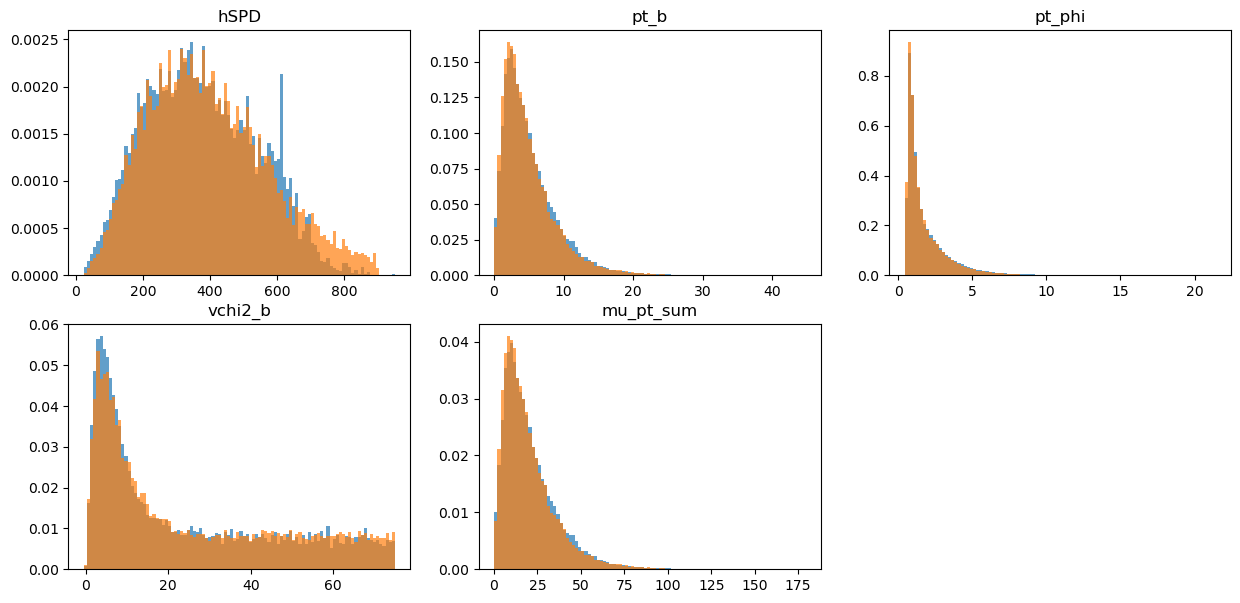

In [25]:
# define base reweighter
reweighter_base = reweight.GBReweighter(n_estimators=50, 
                                        learning_rate=0.1, max_depth=3, min_samples_leaf=1000, 
                                        gb_args={'subsample': 0.4})
reweighter = reweight.FoldingReweighter(reweighter_base, n_folds=2)
# it is not needed divide data into train/test parts; rewighter can be train on the whole samples
reweighter.fit(original, target)

# predict method provides unbiased weights prediction for the whole sample
# folding reweighter contains two reweighters, each is trained on one half of samples
# during predictions each reweighter predicts another half of samples not used in training
folding_weights = reweighter.predict_weights(original)

draw_distributions(original, target, folding_weights)

### GB discrimination for reweighting rule

In [26]:
data = numpy.concatenate([original, target])
labels = numpy.array([0] * len(original) + [1] * len(target))

weights = {}
weights['original'] = original_weights
weights['2-folding'] = folding_weights


for name, new_weights in weights.items():
    W = numpy.concatenate([new_weights / new_weights.sum() * len(target), [1] * len(target)])
    Xtr, Xts, Ytr, Yts, Wtr, Wts = train_test_split(data, labels, W, random_state=42, train_size=0.51)
    clf = GradientBoostingClassifier(subsample=0.3, n_estimators=30).fit(Xtr, Ytr, sample_weight=Wtr)
    
    print(name, roc_auc_score(Yts, clf.predict_proba(Xts)[:, 1], sample_weight=Wts))

original 0.8877404955779229
2-folding 0.5553283478026106
